> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
%pip install -q coptpy numpy pandas


In [ ]:
# This case needs data files. Colab opens the notebook alone, so fetch them here.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/Sudoku_Game/'
FILES = [
    'sudoku.csv',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')


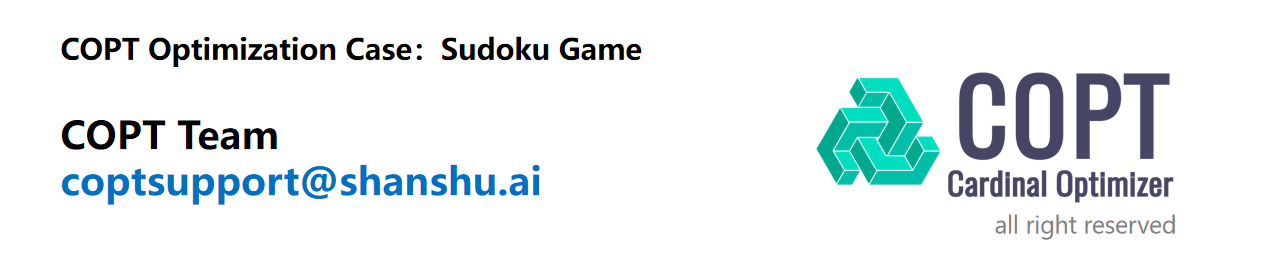

# Sudoku Game Code Implementation

## Steps for Solving Sudoku Game Using COPT Modeling

1. **Import the COPT-Python interface library** `coptpy`

2. Add/import model **data**

3. Create **Solving Environment** and Solving **Model**

4. Build the model and add the **three elements of the model** in sequence
    - **Decision Variables**: Integer type (0-1 type)
    - **Objective Function**
    - **Constraints**: 
      - Assign initial value to the chessboard
      - Each grid $(i,j)$ must and can only fill in one number
      - The number k can only appear once in each line ($i\in \{1, ..., 9\}$)
      - The number k can only appear once in each column ($j\in \{1, ..., 9\}$)
      - Each number k in the palace can only appear once

6. **Solve**

7. View and analyze solution **results**

## 1. Import coptpy and third-party packages

In [1]:
# Import third-party packages
from coptpy import *
import numpy as np
import pandas as pd

`pandas` is used to read external data for chessboard initialization (`pandas.read_csv()`), and `numpy` is used to construct a sparse matrix to represent the chessboard (`np.zeros(shape, dtype)`)

## 2. Chessboard initialization

**(1) Board size:**

$$
\begin{aligned}
&The size of the entire Sudoku board: 9\times 9\\
& palace size: 3\times 3 \\
\end{aligned}
$$

**(2) Construct the chessboard and assign the initial value to the grid: read in the initial data**

Call `pd.read_csv(filename, dtype)` to read external data and store it in the `DataFrame` object `sudoku_info`.

In [3]:
# Sudoku board initialization
sudoku_info = pd.read_csv('sudoku.csv', dtype=int)
sudoku_info.head(10)

,row,col,value
0,0,5,2
1,0,6,9
2,0,7,3
3,1,7,1
4,1,8,5
5,2,1,4
6,2,2,6
7,2,8,7
8,3,1,6
9,3,3,8


`sudoku_info` contains the initial assignment information of the Sudoku board. Each row in the table represents: the initial numerical value of the grid (row, col). Grids that do not appear have no initial assignment. for example:

|row|col|value|
|---|---|---|
|0|5|2|
|0|6|9|

The initial value assigned to grid (0,5) is the number 2, and the initial value assigned to grid (0,6) is the number 9.

Construct a 9X9 **sparse matrix** `SUDOKU_BOARD` to represent the initial Sudoku board. The elements of the matrix are generated based on `sudoku_info`.
Among them, the coordinates (row, col) that appear in `sudoku_info` take the corresponding value, and the coordinates that do not appear in `sudoku_info` take the default value 0.

`DataFrame.iterrows()` is a generator that iterates over the rows (Rows) in `DataFrame`, returning the **index (idx)** of each row and an **object (r)** containing the row itself. .

In [5]:
# build 9x9 matrix 
SUDOKU_BOARD = np.zeros([9, 9], dtype=int)
for idx,r in sudoku_info.iterrows():
    print("index{0}:({1},{2})={3}".format(idx, r['row'], r['col'], r['value']))
    SUDOKU_BOARD[r['row'], r['col']] = r['value']
    

index0:(0,5)=2
index1:(0,6)=9
index2:(0,7)=3
index3:(1,7)=1
index4:(1,8)=5
index5:(2,1)=4
index6:(2,2)=6
index7:(2,8)=7
index8:(3,1)=6
index9:(3,3)=8
index10:(3,5)=4
index11:(3,8)=9
index12:(4,2)=8
index13:(4,3)=1
index14:(4,5)=7
index15:(4,6)=6
index16:(5,0)=4
index17:(5,3)=2
index18:(5,5)=9
index19:(5,7)=5
index20:(6,0)=3
index21:(6,6)=2
index22:(6,7)=9
index23:(7,0)=7
index24:(7,1)=9
index25:(8,1)=2
index26:(8,2)=5
index27:(8,3)=3


<font color="#B22222">
<b>Note:</b>
</font>

Different from $\forall i,j \in \{1, ..., 9\}$ in the previous mathematical model, when the code is implemented, in `sudoku_info` and sparse matrix `SUDOKU_BOARD`, since the starting value of the subscript is 0, where `row` and `col`$\in\{0,1,\cdots,8\}$

In [7]:
print("Initial Sudoku board：\n")
print(SUDOKU_BOARD)

Initial Sudoku board：

[[0 0 0 0 0 2 9 3 0]
 [0 0 0 0 0 0 0 1 5]
 [0 4 6 0 0 0 0 0 7]
 [0 6 0 8 0 4 0 0 9]
 [0 0 8 1 0 7 6 0 0]
 [4 0 0 2 0 9 0 5 0]
 [3 0 0 0 0 0 2 9 0]
 [7 9 0 0 0 0 0 0 0]
 [0 2 5 3 0 0 0 0 0]]


**(3) Display the initial chessboard: visualization tool**

Through `print_board(SUDOKU_BOARD)`, the two-dimensional array `SUDOKU_BOARD` is presented in a more beautiful and clear way.

In [9]:
# Sudoku board visualization tool
def print_board(board): 
    row, col = board.shape
    for i in range(row):
        print_row = ''
        for j in range(col):
            sep = ' ' if j%3 != 0 else'|'
            if board[i,j] == 0:
                print_row += '{}{}'.format(sep, '_')
            else:
                print_row += '{}{}'.format(sep, board[i,j])
        print_row += '|'
        print(print_row)
        if (i+1)%3 == 0 and i != row-1:
            print('-'*len(print_row))
        
print_board(SUDOKU_BOARD)

|_ _ _|_ _ 2|9 3 _|
|_ _ _|_ _ _|_ 1 5|
|_ 4 6|_ _ _|_ _ 7|
-------------------
|_ 6 _|8 _ 4|_ _ 9|
|_ _ 8|1 _ 7|6 _ _|
|4 _ _|2 _ 9|_ 5 _|
-------------------
|3 _ _|_ _ _|2 9 _|
|7 9 _|_ _ _|_ _ _|
|_ 2 5|3 _ _|_ _ _|


## 3. Create COPT solution environment

In [11]:
# Create COPT environment
env = Envr()
# Create COPT model
model = env.createModel("sudoku")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 4. Build the model

### 4.1 Add decision variables
$$
X_{ijk}\in \{0,1\},\qquad \forall i,j,k\in \{1, ..., 9\}
$$

Call `Model.addVars()` to add $X_{ijk}$ in batches. Since the decision variable subscript has three dimensions: $i, j, k$, and the known dimension scale is $9\times9\times9$, so by specifying Variables are added in the form of subscripted scales. At the same time, since the decision variable is an integer variable of 0-1, specify the parameter `vtype=COPT.BINARY` and return a `tupledict` class object.

In [13]:
# Add variables: x
x = model.addVars(9, 9, 9, vtype=COPT.BINARY)
print("Number of decision variables in the model:", model.getAttr(attrname="Cols"))

Number of decision variables in the model: 729


<font color="#B22222">
<b>Note: Subscript correspondence</b>
</font>

1. The `x` returned by calling `Model.addVars()` is an object of the `tupledict` class, which stores all decision variables in the model. The starting index is \[0,0,0\];
2. The decision variables $X_{ijk},(\forall i,j,k\in \{1, ..., 9\})$ that we defined in the previous mathematical model have a starting subscript of (1 ,1,1);
3. The two-dimensional sparse matrix SUDOKU_BOARD represents the Sudoku board, the starting subscript is \[0,0\], and the filled-in numbers range from 1 to 9.

For example: $X_{111}=1 \Longleftrightarrow$ `x[0,0,0]=1` $\Longleftrightarrow SUDOKU\_BOARD[0,0]=1$, which means: checkerboard grid (first Row 1) fill in the number 1.

The specific corresponding relationships are as follows:

|Mathematical form:$X_{ijk}$|COPT model:`x`|Two-dimensional matrix|Meaning|
|:---:|:---:|:---:|:---:|
|$i$|$i-1$|$i-1$|row|
|$j$|$j-1$|$i-1$|Column|
|$k$|$k-1$|$k$|Numbers filled in the grid|

$$
\forall i,j,k\in \{1, ..., 9\}
$$

### 4.2 Add constraints
**(1) Assign initial value to the chessboard: If the initial chessboard grid $(i,j)$ is given a number k, then**
$$
X_{i,j,k} = 1
$$

The two-dimensional sparse matrix `SUDOKU_BOARD` represents a Sudoku board, where `SUDOKU_BOARD[i][j]=0` means that the grid $(i,j)$ has not been assigned an initial value and needs to be filled in with numbers; otherwise, it means that the grid $( i,j)$ already has an initial value $k$, and the decision variable `x[i,j,k]=1`.

In [15]:
# Fix variables associated with cells whose values are pre-specified
model.addConstrs(x[i,j,SUDOKU_BOARD[i][j] - 1] == 1 for i in range(9) for j in range(9) if SUDOKU_BOARD[i][j] != 0)
print("The number of constraints after the chessboard is assigned an initial value:",model.getAttr("rows"))

The number of constraints after the chessboard is assigned an initial value: 28


**(2) Grid: Each grid $(i,j)$ must and can only fill in one number**
$$
\sum_{k=1}^9 X_{ijk} = 1,\qquad \forall i,j \in \{1, ..., 9\}
$$

In [17]:
## Each cell only takes one value
model.addConstrs(x.sum(i, j, "*") == 1 
                 for i in range(9)
                 for j in range(9))
print("After adding grid constraints, the number of constraints:",model.getAttr("rows"))

After adding grid constraints, the number of constraints: 109


In Sudoku problems, the advantages of `tupledict.sum()` are very obvious, it can make adding constraints clear and convenient. Specifying the matching pattern `pattern=(i,j,"*")` means that we fix the grid coordinates and add the 0-1 variables $X_{ijk} $ indicating whether to fill in the numbers 1 to 9.

In contrast, another implementation is a three-level loop nested structure:
```python
model.addConstrs(quicksum(x[i,j,k] for k in range(9)) == 1
                  for i in range(9)
                  for j in range(9))
```

**(3) Line: The number k can only appear once in each line ($i\in \{1, ..., 9\}$)**
$$
\sum_{j} X_{ijk} = 1,\qquad \forall i,k \in \{1, ..., 9\}
$$

In [19]:
# Each value appears once per row

model.addConstrs(x.sum(i, "*", k) == 1 
                 for i in range(9)
                 for k in range(9))
print("After adding row constraints, the number of model constraints:",model.getAttr("rows"))

After adding row constraints, the number of model constraints: 190


Call `tupledict.sum()` and specify the matching pattern `pattern=(i,"*", k)`, which means specifying the row $i$ and the number $k$, and matching the 0-1 variable $X_{ijk} $ add.

Similarly, if implemented with `quicksum()`, three levels of loop nesting are required, which is very cumbersome:
```python
model.addConstrs(quicksum(x[i,j,k] for j in range(9)) == 1
                  for i in range(9)
                  for k in range(9))
```

**(4) Column: The number k can only appear once in each column ($j\in \{1, ..., 9\}$)**
$$
\sum_{i} X_{ijk} = 1,\qquad \forall k,j \in \{1, ..., 9\}
$$

In [21]:
# Each value appears once per column

model.addConstrs(x.sum("*", j, k) == 1 
                 for j in range(9)
                 for k in range(9))
print("After adding column constraints, the number of model constraints:",model.getAttr("rows"))

After adding column constraints, the number of model constraints: 271


Call `tupledict.sum()` and specify the matching pattern `pattern=("*",j, k)`, which means specifying the column and number $k$, and 0-1 corresponding to the number $k$ in the specified column Variables $X_{ijk} $ are added.

Similarly, if implemented with `quicksum()`, three levels of loop nesting are required:
```python
model.addConstrs(quicksum(x[i,j,k] for i in range(9)) == 1
                  for j in range(9)
                  for k in range(9))
````

**(5) Palace: Each number k in the palace can only appear once**
$$
\sum_{i\in \{3p, ..., 3(p+1)\},j\in \{3q, ..., 3(q+1)\}} X_{ijk} = 1, \qquad \forall p,q \in \{1, 2, 3\}, k\in\{1, ..., 9\}
$$

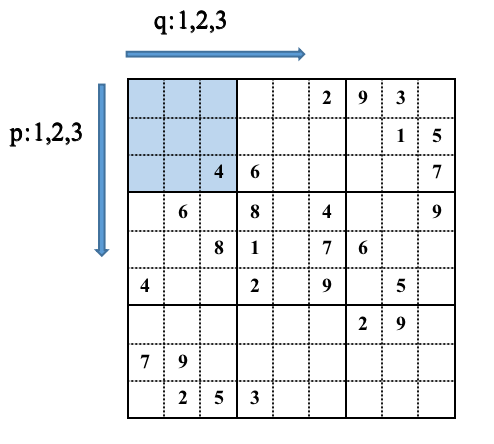

<center>Figure 4: $p, q$ control the position of the palace on the chessboard</center>

In [23]:
# Each value appears once per subgrid
model.addConstrs(x.sum(range(p*3, (p+1)*3), range(q*3, (q+1)*3), k) == 1
    for k in range(9)
    for p in range(3)
    for q in range(3))
print("After adding palace constraints, the number of model constraints:",model.getAttr("rows"))

After adding palace constraints, the number of model constraints: 352


Here $p$ and $q$ are used to control the position movement of the palace on the Sudoku board, where $p$ controls the movement of the palace in the row direction, and $q$ controls the movement of the palace in the column direction.

For example, when $p=1$,$q=1$, the position of the corresponding palace on the chessboard is the blue area in the upper left corner.

Another implementation, multi-level loop nesting:
```python
model.addConstrs(
     quicksum(x[i, j, k] for i in range(p*3, (p+1)*3) for j in range(q*3, (q+1)*3)) == 1
     for k in range(9)
     for p in range(3)
     for q in range(3))
```

## 5. Solving and visual display

### 5.1 Solve and obtain the results

In [25]:
model.solve()

Model fingerprint: 623eacda

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    352 rows, 729 columns and 2944 non-zero elements
    729 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

Problem was solved during presolve

Best solution   : 0.000000000
Best bound      : 0.000000000
Best gap        : 0.0000%
Solve time      : 0.01
Solve node      : 0
MIP status      : solved
Solution status : integer optimal (relative gap limit 0.0001)

Violations      :     absolute     relative
    bounds      :            0            0
    rows        :            0            0
    integrality :            0


### 5.2 Visualizing Sudoku solution results

In [27]:
# Visualize Sudoku solution results

sudoku_solution = SUDOKU_BOARD.copy()
for i in range(9):
    for j in range(9):
        for k in range(9):
            if x[i,j,k].x > 0:
                sudoku_solution[i,j] = k+1
                
print_board(sudoku_solution)

|8 1 7|5 4 2|9 3 6|
|2 3 9|7 8 6|4 1 5|
|5 4 6|9 1 3|8 2 7|
-------------------
|1 6 2|8 5 4|3 7 9|
|9 5 8|1 3 7|6 4 2|
|4 7 3|2 6 9|1 5 8|
-------------------
|3 8 4|6 7 5|2 9 1|
|7 9 1|4 2 8|5 6 3|
|6 2 5|3 9 1|7 8 4|


Since the value of the two-dimensional matrix `SUDOKU_BOARD[i][j]` is 1~9, and the value of the subscript k representing the number in the decision variable `x[i,j,k]` is \[0, 8\ ]. Therefore, when visually outputting the solution results, `sudoku_solution[i,j] = k+1`